In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("gene_expression_ml.csv")

In [3]:
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gene One        3000 non-null   float64
 1   Gene Two        3000 non-null   float64
 2   Cancer Present  3000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 70.4 KB


In [6]:
df.isnull().count()

Gene One          3000
Gene Two          3000
Cancer Present    3000
dtype: int64

In [13]:
df.columns

Index(['Gene One', 'Gene Two', 'Cancer Present'], dtype='object')

In [14]:
df["Cancer Present"].value_counts()

Cancer Present
1    1500
0    1500
Name: count, dtype: int64

In [8]:
df.describe()

,Gene One,Gene Two,Cancer Present
count,3000.000000,3000.000000,3000.000000
mean,5.600133,5.410467,0.500000
std,1.828388,1.729081,0.500083
min,1.000000,1.000000,0.000000
25%,4.300000,4.000000,0.000000
50%,5.600000,5.400000,0.500000
75%,6.900000,6.700000,1.000000
max,10.000000,10.000000,1.000000


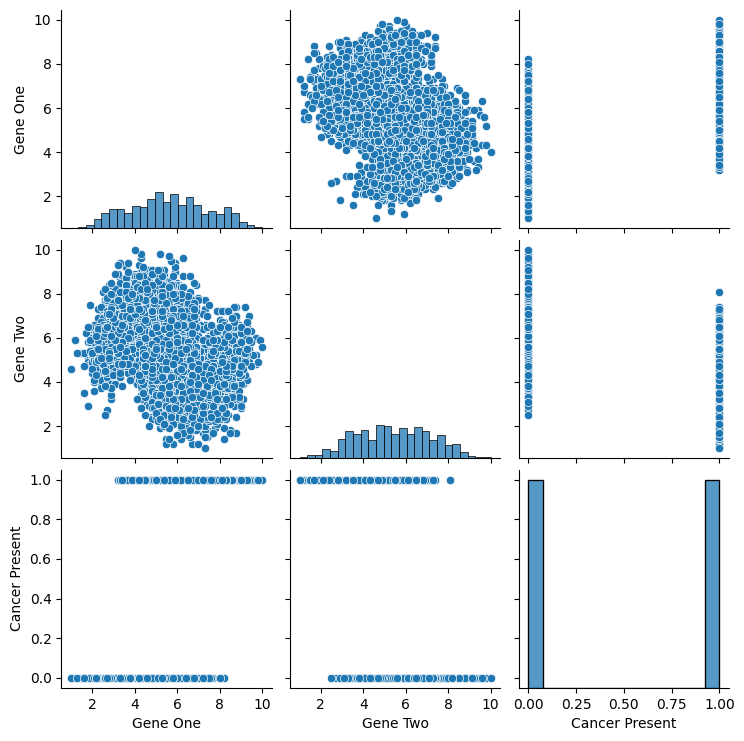

In [9]:
sns.pairplot(df)

##### Observations 
* Mean and median(50 percentile are same ) hence it is no skewed data.
* pairplot shows Gaussian dist/normal dist
* Balanced dataset

<Axes: xlabel='Gene One', ylabel='Gene Two'>

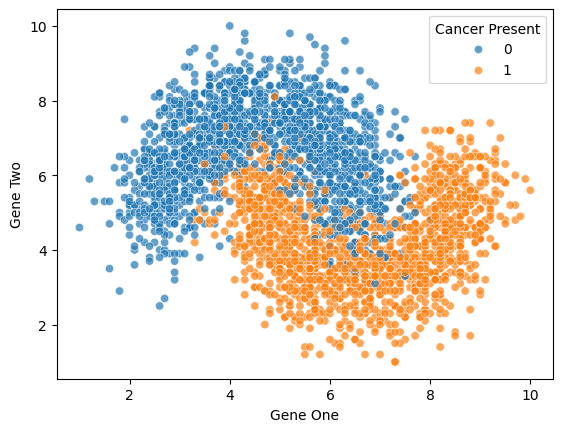

In [16]:
sns.scatterplot(x = "Gene One", y = "Gene Two", data = df, hue ="Cancer Present", alpha = 0.7)

(4.0, 8.0)

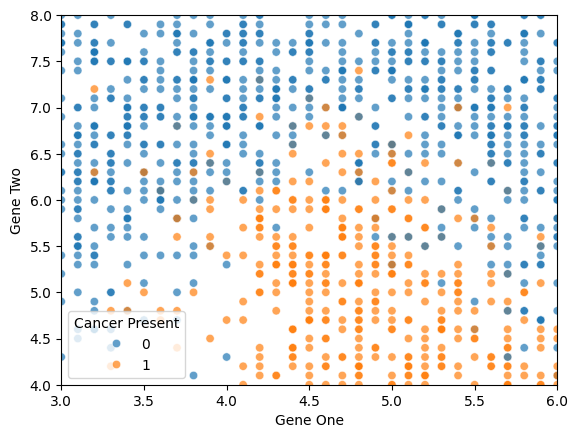

In [17]:
sns.scatterplot(x = "Gene One", y = "Gene Two", data = df, hue ="Cancer Present", alpha = 0.7) 
plt.xlim(3,6)
plt.ylim(4,8)

### Train Test split & Data scaling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

In [20]:
X = df.drop("Cancer Present", axis = 1)
y = df["Cancer Present"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=101)

In [22]:
sc = StandardScaler()

In [25]:
sc_X_train = sc.fit_transform(X_train)
sc_X_test = sc.transform(X_test)

In [26]:
from sklearn.neighbors import KNeighborsClassifier

In [27]:
knn_model = KNeighborsClassifier(n_neighbors=1)

In [28]:
knn_model.fit(sc_X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

### Model Evaluation

In [30]:
y_pred = knn_model.predict(sc_X_test)

In [31]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [32]:
accuracy_score(y_test, y_pred)

0.9166666666666666

In [33]:
confusion_matrix(y_test, y_pred)

array([[381,  42],
       [ 33, 444]])

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       423
           1       0.91      0.93      0.92       477

    accuracy                           0.92       900
   macro avg       0.92      0.92      0.92       900
weighted avg       0.92      0.92      0.92       900



### Elbow method for chossing Reasonable K

In [35]:
test_error_rates = []
for k in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors= k)
    knn.fit(sc_X_train, y_train)

    y_pred_test = knn.predict(sc_X_test)

    test_error = 1 - accuracy_score(y_test, y_pred_test)
    test_error_rates.append(test_error)
    

In [36]:
test_error_rates

[0.08333333333333337,
 0.0888888888888889,
 0.07111111111111112,
 0.06777777777777783,
 0.06555555555555559,
 0.06000000000000005,
 0.06444444444444442,
 0.06333333333333335,
 0.06666666666666665,
 0.06333333333333335,
 0.06888888888888889,
 0.06222222222222218,
 0.06444444444444442,
 0.06333333333333335,
 0.06666666666666665,
 0.06222222222222218,
 0.06000000000000005,
 0.061111111111111116,
 0.06333333333333335,
 0.06333333333333335,
 0.06222222222222218,
 0.06666666666666665,
 0.061111111111111116,
 0.05888888888888888,
 0.06222222222222218,
 0.06333333333333335,
 0.06222222222222218,
 0.061111111111111116,
 0.06222222222222218]

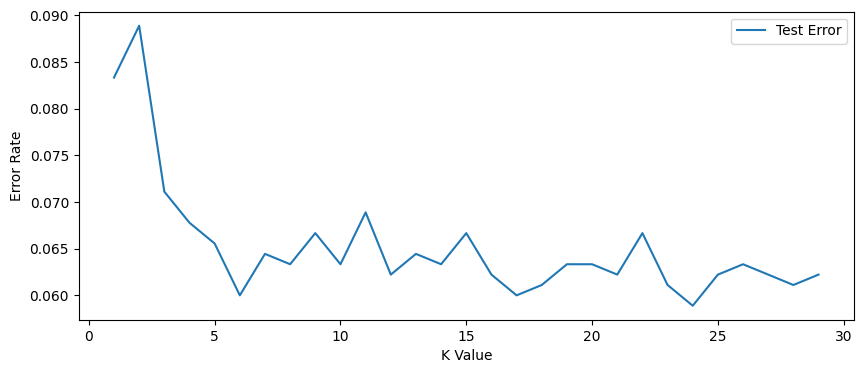

In [37]:
plt.figure(figsize=(10,4))
plt.plot(range(1,30), test_error_rates, label = "Test Error")
plt.legend()
plt.ylabel("Error Rate")
plt.xlabel("K Value")
plt.show()

### Other way : Cross validation and Grid Search for K value:

In [46]:
# Using pipeline:

In [47]:
scaler = StandardScaler()
knn = KNeighborsClassifier()

In [48]:
knn.get_params().keys()

dict_keys(['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])

In [49]:
operations = [("scaler", scaler), ("knn", knn)]

In [50]:
from sklearn.pipeline import Pipeline

In [51]:
pipe = Pipeline(operations)

In [52]:
from sklearn.model_selection import GridSearchCV 

In [54]:
k_values = list(range(1, 20))
k_values

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

In [55]:
param_grid = {"knn__n_neighbors": k_values}

* chosen_string_name + 2 underscore + parameter key name
* chosen model name + __ + parameter name
* knn__n_neighnors 


In [56]:
full_cv_classifier = GridSearchCV(pipe, param_grid, cv = 5, scoring= "accuracy")

In [57]:
full_cv_classifier.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19]},
             scoring='accuracy')

In [59]:
full_cv_classifier.best_estimator_.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('knn', KNeighborsClassifier(n_neighbors=19))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'knn': KNeighborsClassifier(n_neighbors=19),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'knn__algorithm': 'auto',
 'knn__leaf_size': 30,
 'knn__metric': 'minkowski',
 'knn__metric_params': None,
 'knn__n_jobs': None,
 'knn__n_neighbors': 19,
 'knn__p': 2,
 'knn__weights': 'uniform'}

In [61]:
len(k_values)

19

In [63]:
full_cv_classifier.cv_results_["mean_test_score"]

array([0.89857143, 0.90095238, 0.91714286, 0.91857143, 0.92428571,
       0.92428571, 0.9252381 , 0.92714286, 0.92666667, 0.92714286,
       0.9252381 , 0.92714286, 0.92857143, 0.92857143, 0.92666667,
       0.92904762, 0.92714286, 0.93047619, 0.93095238])

### Final model:

In [65]:
scaler = StandardScaler()
knn19 = KNeighborsClassifier(n_neighbors= 19 )

In [66]:
operations = [("scaler", scaler), ("knn19", knn19)]

In [67]:
pipe = Pipeline(operations)

In [68]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn19', KNeighborsClassifier(n_neighbors=19))])

In [70]:
pipe_pred = pipe.predict(X_test)

In [72]:
print(classification_report(y_test, pipe_pred))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       423
           1       0.93      0.95      0.94       477

    accuracy                           0.94       900
   macro avg       0.94      0.94      0.94       900
weighted avg       0.94      0.94      0.94       900



##### Predicting new data :

In [76]:
pipe.predict_proba([[4.6, 6.7],[4.6, 7] ])

/home/saji/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.68421053, 0.31578947],
       [0.89473684, 0.10526316]])

In [77]:
pipe.predict([[4.6, 6.7],[4.6, 7] ])

/home/saji/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0, 0])